In [1]:
import pandas as pd
import warnings
import numpy as np
from time import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, RepeatedStratifiedKFold
from scipy.stats import randint, loguniform, uniform
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.ensemble import GradientBoostingRegressor
# import xgboost as xgb
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

warnings.filterwarnings("ignore")

wine_data = pd.read_csv('winequality-red.csv', sep=';')

print("--- Initial Data Overview ---")
print("\nFirst 5 Rows:")
print(wine_data.head())
print(f"\nDataset Shape: {wine_data.shape}")
print("\nDataset Info:")
wine_data.info()
print("\nDescriptive Statistics:")
print(wine_data.describe())

X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

print("\n--- Data Preparation ---")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Unique target values: {sorted(y.unique())}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5, stratify=y
)

print("\n--- Data Splitting ---")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

--- Initial Data Overview ---

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5

Starting RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END regress__activation=tanh, regress__alpha=0.00017910061496349768, regress__hidden_layer_sizes=(50, 25), regress__solver=adam;, score=0.347 total time=  42.5s
[CV 2/5] END regress__activation=tanh, regress__alpha=0.00017910061496349768, regress__hidden_layer_sizes=(50, 25), regress__solver=adam;, score=0.231 total time=   7.7s
[CV 3/5] END regress__activation=tanh, regress__alpha=0.00017910061496349768, regress__hidden_layer_sizes=(50, 25), regress__solver=adam;, score=0.125 total time=   8.2s
[CV 4/5] END regress__activation=tanh, regress__alpha=0.00017910061496349768, regress__hidden_layer_sizes=(50, 25), regress__solver=adam;, score=0.271 total time=   6.6s
[CV 5/5] END regress__activation=tanh, regress__alpha=0.00017910061496349768, regress__hidden_layer_sizes=(50, 25), regress__solver=adam;, score=0.279 total time=   5.4s
[CV 1/5] END regress__activation=relu, regress__alpha=0.0

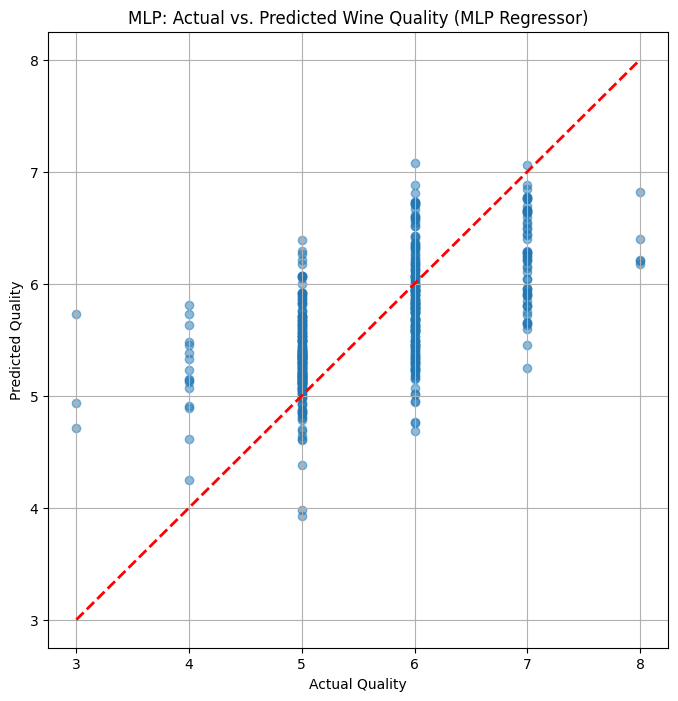

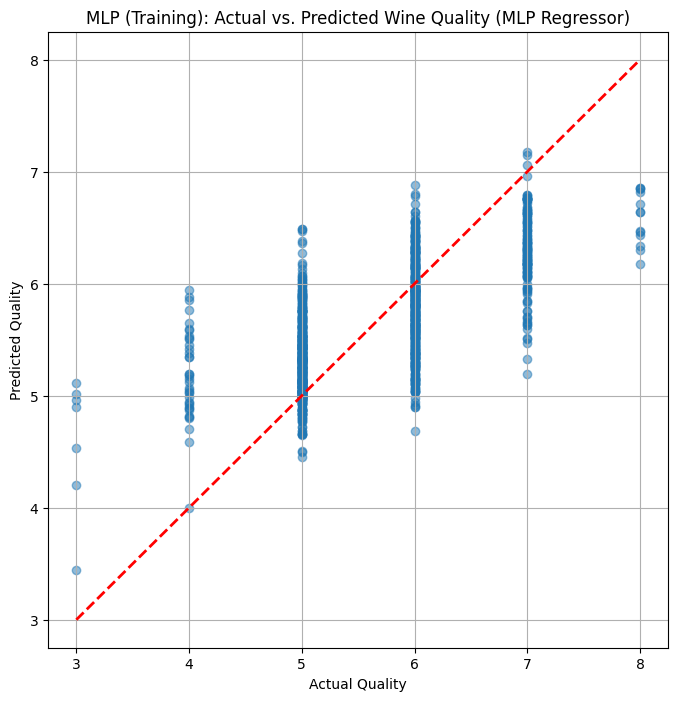

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.25      0.06      0.10        16
           5       0.67      0.69      0.68       204
           6       0.53      0.62      0.57       192
           7       0.49      0.32      0.38        60
           8       0.00      0.00      0.00         5

    accuracy                           0.59       480
   macro avg       0.32      0.28      0.29       480
weighted avg       0.57      0.59      0.57       480



In [2]:
pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("regress", MLPRegressor(max_iter=5000, random_state=5))] # Add random_state for reproducibility
)

model_params = {
    'regress__alpha': loguniform(1e-4, 10),
    'regress__solver': ['sgd', 'adam'],
    'regress__hidden_layer_sizes': [
        (100,),              
        (50, 25),           
    ],
    'regress__activation': ['tanh', 'relu'] 
}

n_iter = 20
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=model_params,
    n_iter=n_iter,
    verbose=3
)

print("Starting RandomizedSearchCV...")
start = time()
random_search.fit(X_train, y_train)
print(f"RandomizedSearchCV took {time() - start:.2f} seconds for {n_iter} candidate settings.")
print("\nBest parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2  = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2  = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2) # The "perfect prediction" line
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("MLP: Actual vs. Predicted Wine Quality (MLP Regressor)")
plt.grid()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_train, alpha=0.5)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r--', lw=2) # The "perfect prediction" line
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("MLP (Training): Actual vs. Predicted Wine Quality (MLP Regressor)")
plt.grid()
plt.show()

y_pred_test_class = np.round(y_pred_test).astype(int)
y_pred_test_class = np.clip(y_pred_test_class, y.min(), y.max())
print('Test Classification Report')
print(classification_report(y_test, y_pred_test_class))
plt.show()

Starting SVR hyperparameter tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.00041702055892034045, regress__kernel=rbf;, score=0.334 total time=   0.1s
[CV 2/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.00041702055892034045, regress__kernel=rbf;, score=0.283 total time=   0.1s
[CV 3/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.00041702055892034045, regress__kernel=rbf;, score=0.257 total time=   0.1s
[CV 4/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.00041702055892034045, regress__kernel=rbf;, score=0.299 total time=   0.1s
[CV 5/5] END regress__C=0.7726319876517099, regress__degree=3, regress__gamma=0.00041702055892034045, regress__kernel=rbf;, score=0.292 total time=   0.1s
[CV 1/5] END regress__C=827.5228539305429, regress__degree=2, regress__gamma=0.006842764422737328, regress__kernel=rbf;, scor

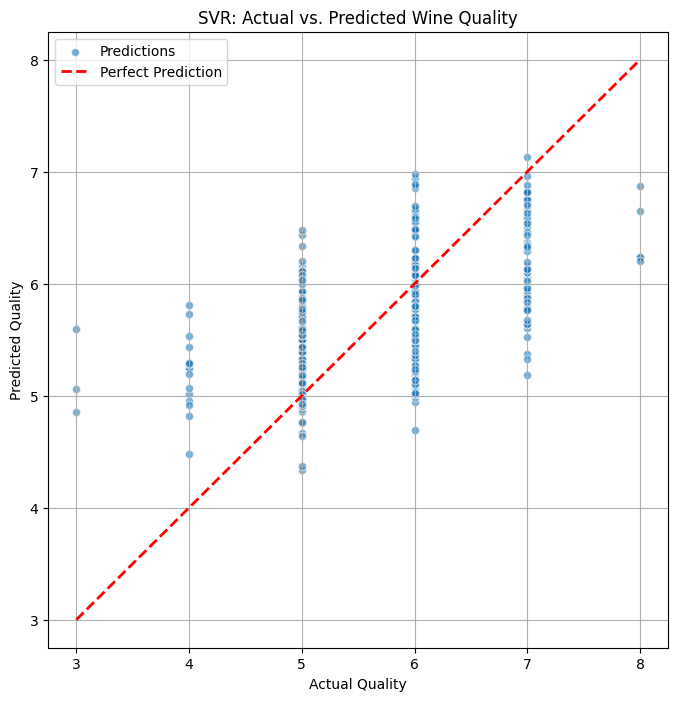

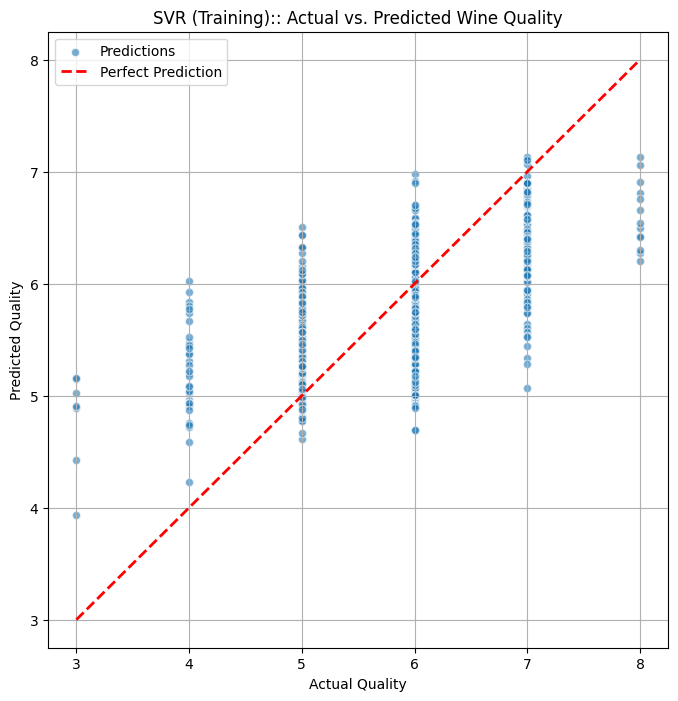

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.33      0.06      0.11        16
           5       0.66      0.74      0.70       204
           6       0.55      0.59      0.57       192
           7       0.50      0.35      0.41        60
           8       0.00      0.00      0.00         5

    accuracy                           0.60       480
   macro avg       0.34      0.29      0.30       480
weighted avg       0.57      0.60      0.58       480



In [3]:
pipeline = Pipeline([
    ('preprocess', StandardScaler()),
    ('regress', SVR())
])

model_params = {
    'regress__C': loguniform(1e-1, 1e3),
    'regress__gamma': loguniform(1e-4, 1e-1),
    'regress__kernel': ['rbf', 'poly', 'sigmoid'],
    'regress__degree': [2, 3, 4]
}

n_iter = 20
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=model_params,
    n_iter=n_iter,
    verbose=3,
    random_state=5
)

print("Starting SVR hyperparameter tuning...")
random_search.fit(X_train, y_train)

print("\nBest SVR parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2  = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2  = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='w', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("SVR: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_train, alpha=0.6, edgecolors='w', label='Predictions')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("SVR (Training):: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

y_pred_test_class = np.round(y_pred_test).astype(int)
y_pred_test_class = np.clip(y_pred_test_class, y.min(), y.max())
print('Test Classification Report')
print(classification_report(y_test, y_pred_test_class))
plt.show()

In [4]:

# dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
# dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

# params = {"objective": "reg:squarederror"}
# n = 100

# model = xgb.train(
#    params=params,
#    dtrain=dtrain_reg,
#    num_boost_round=n
# )

# y_pred_train = model.predict(dtrain_reg)
# y_pred_test = model.predict(dtest_reg)


# train_mse = mean_squared_error(y_train, y_pred_train)
# test_mse = mean_squared_error(y_test, y_pred_test)
# print(f"Training MSE: {train_mse}")
# print(f"Testing MSE: {test_mse}")

# train_r2  = r2_score(y_train, y_pred_train)
# test_r2   = r2_score(y_test, y_pred_test)
# train_mad = mean_absolute_error(y_train, y_pred_train)
# test_mad  = mean_absolute_error(y_test, y_pred_test)

# print(f"Training R2: {train_r2}, Training MAD: {train_mad}")
# print(f"Testing R2: {test_r2}, Testing MAD: {test_mad}")

# plt.figure(figsize=(8, 8))
# plt.scatter(y_test, y_pred_test, alpha=0.6, label='Predictions')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
# plt.xlabel("Actual Quality")
# plt.ylabel("Predicted Quality")
# plt.title("XGBoost: Actual vs. Predicted Wine Quality")
# plt.legend()
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(8, 8))
# plt.scatter(y_train, y_pred_train, alpha=0.6, edgecolors='w', label='Predictions')
# plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
# plt.xlabel("Actual Quality")
# plt.ylabel("Predicted Quality")
# plt.title("XGBoost (Training): Actual vs. Predicted Wine Quality")
# plt.legend()
# plt.grid(True)
# plt.show()

Starting hyperparameter tuning for Random Forest Regressor...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END regress__max_depth=4, regress__n_estimators=477;, score=0.471 total time=   1.5s
[CV 2/5] END regress__max_depth=4, regress__n_estimators=477;, score=0.312 total time=   1.3s
[CV 3/5] END regress__max_depth=4, regress__n_estimators=477;, score=0.344 total time=   1.4s
[CV 4/5] END regress__max_depth=4, regress__n_estimators=477;, score=0.376 total time=   1.3s
[CV 5/5] END regress__max_depth=4, regress__n_estimators=477;, score=0.388 total time=   1.4s
[CV 1/5] END regress__max_depth=11, regress__n_estimators=183;, score=0.531 total time=   0.8s
[CV 2/5] END regress__max_depth=11, regress__n_estimators=183;, score=0.408 total time=   0.8s
[CV 3/5] END regress__max_depth=11, regress__n_estimators=183;, score=0.420 total time=   0.9s
[CV 4/5] END regress__max_depth=11, regress__n_estimators=183;, score=0.448 total time=   0.9s
[CV 5/5] END regress__max_

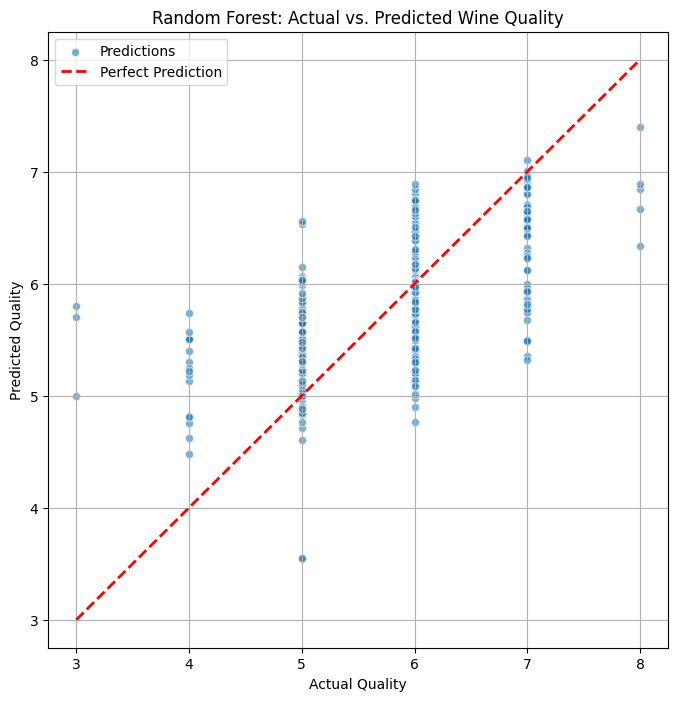

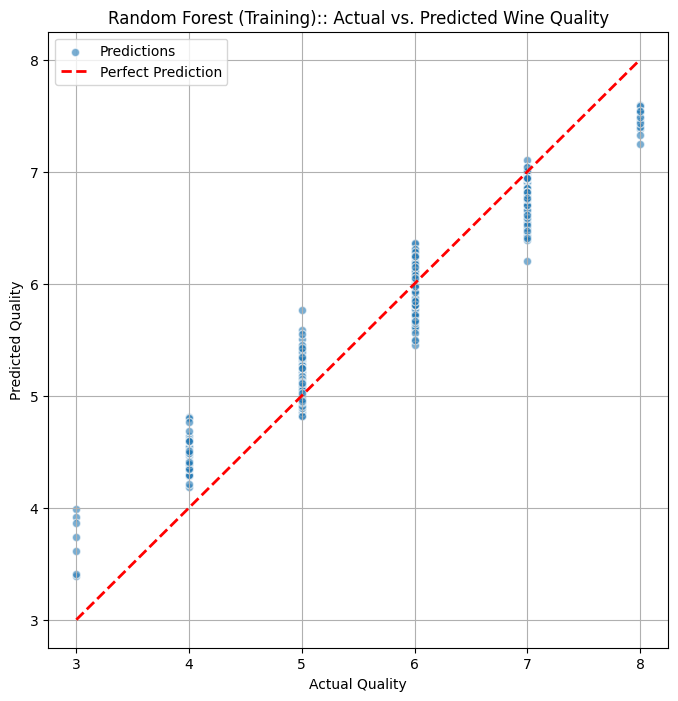

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.33      0.06      0.11        16
           5       0.73      0.78      0.76       204
           6       0.64      0.69      0.66       192
           7       0.58      0.52      0.55        60
           8       0.00      0.00      0.00         5

    accuracy                           0.68       480
   macro avg       0.38      0.34      0.35       480
weighted avg       0.65      0.68      0.66       480



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

pipeline = Pipeline([
    ('preprocess', StandardScaler()),
    ('regress', RandomForestRegressor(random_state=5))
])

model_params = {
    'regress__n_estimators': randint(50, 500),
    'regress__max_depth': randint(1, 20)
}

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)

print("Starting hyperparameter tuning for Random Forest Regressor...")
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
print("\nBest hyperparameters found:")
print(random_search.best_params_)

y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='w', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Random Forest: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_train, alpha=0.6, edgecolors='w', label='Predictions')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Random Forest (Training):: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

y_pred_test_class = np.round(y_pred_test).astype(int)
y_pred_test_class = np.clip(y_pred_test_class, y.min(), y.max())
print('Test Classification Report')
print(classification_report(y_test, y_pred_test_class))
plt.show()

Starting Gradient Boosting hyperparameter tuning with a pipeline...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END regress__max_depth=7, regress__n_estimators=321;, score=0.487 total time=   1.4s
[CV 2/5] END regress__max_depth=7, regress__n_estimators=321;, score=0.407 total time=   1.9s
[CV 3/5] END regress__max_depth=7, regress__n_estimators=321;, score=0.437 total time=   1.5s
[CV 4/5] END regress__max_depth=7, regress__n_estimators=321;, score=0.386 total time=   1.7s
[CV 5/5] END regress__max_depth=7, regress__n_estimators=321;, score=0.439 total time=   1.5s
[CV 1/5] END regress__max_depth=1, regress__n_estimators=210;, score=0.472 total time=   0.2s
[CV 2/5] END regress__max_depth=1, regress__n_estimators=210;, score=0.362 total time=   0.2s
[CV 3/5] END regress__max_depth=1, regress__n_estimators=210;, score=0.341 total time=   0.2s
[CV 4/5] END regress__max_depth=1, regress__n_estimators=210;, score=0.378 total time=   0.2s
[CV 5/5] END regress__ma

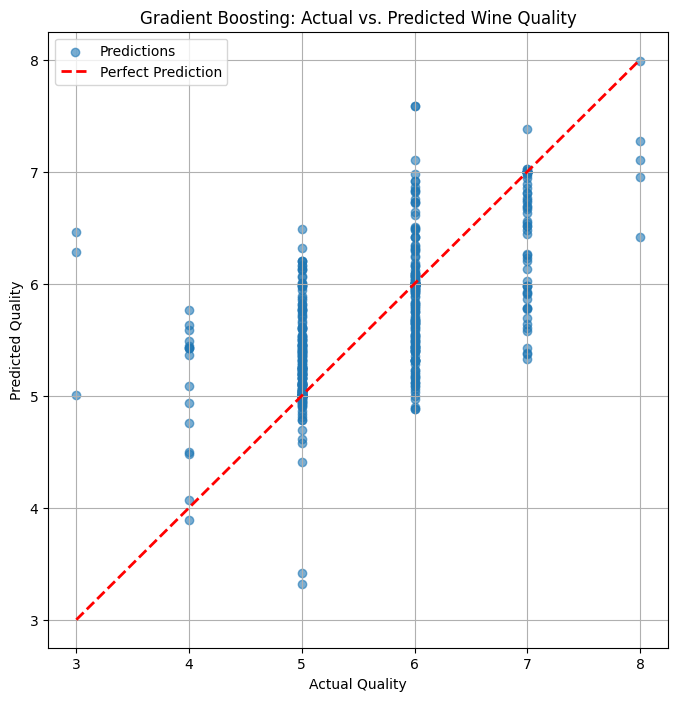

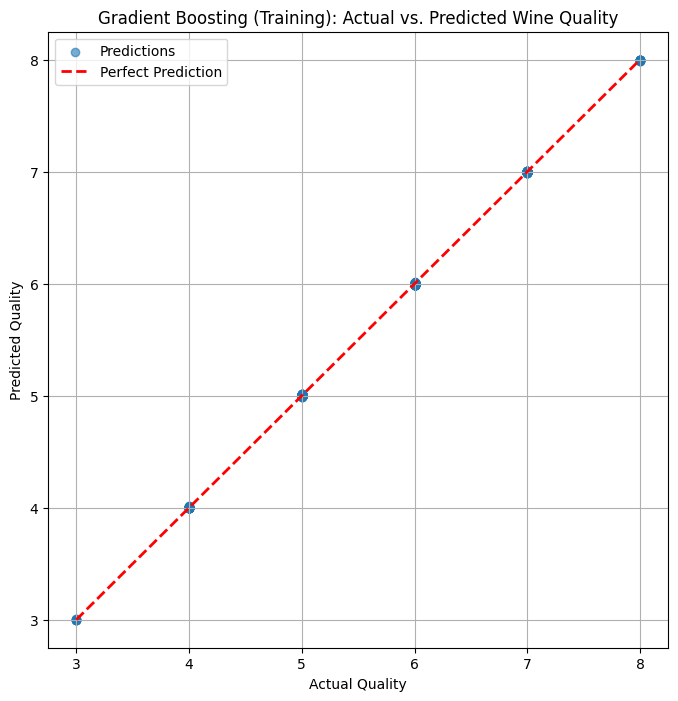

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.80      0.25      0.38        16
           5       0.71      0.75      0.73       204
           6       0.63      0.67      0.65       192
           7       0.65      0.57      0.61        60
           8       0.33      0.20      0.25         5

    accuracy                           0.67       480
   macro avg       0.52      0.41      0.44       480
weighted avg       0.67      0.67      0.66       480

Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.80      0.25      0.38        16
           5       0.71      0.75      0.73       204
           6       0.63      0.67      0.65       192
           7       0.65      0.57      0.61        60
           8       0.33      0.20      0.25         5

    accuracy           

In [ ]:
pipeline = Pipeline([
    ('preprocessing', StandardScaler()),
    ('regress', GradientBoostingRegressor(random_state=5))
])

param_grid = {
    'regress__n_estimators': randint(100, 500),
    'regress__max_depth': randint(3, 10),
    'regress__learning_rate': uniform(0.01, 0.2),
    'regress__subsample': uniform(0.7, 0.3),
    'regress__min_samples_leaf': randint(1, 5)
}

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)

print("Starting Gradient Boosting hyperparameter tuning with a pipeline...")
random_search.fit(X_train, y_train)

print("\nBest Gradient Boosting parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Gradient Boosting Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Gradient Boosting: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_train, alpha=0.6, label='Predictions')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Gradient Boosting (Training): Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

y_pred_test_class = np.round(y_pred_test).astype(int)
y_pred_test_class = np.clip(y_pred_test_class, y.min(), y.max())
print('Test Classification Report')
print(classification_report(y_test, y_pred_test_class))
plt.show()


=== Regression Test Metrics (y_pred_test) ===
RMSE: 0.6319
R²  : 0.3842
MAD : 0.4218
Tolerance accuracy (T=0.5): 66.67%
Tolerance accuracy (T=1.0): 88.12%
REC AUC (0–2.5): 0.8308


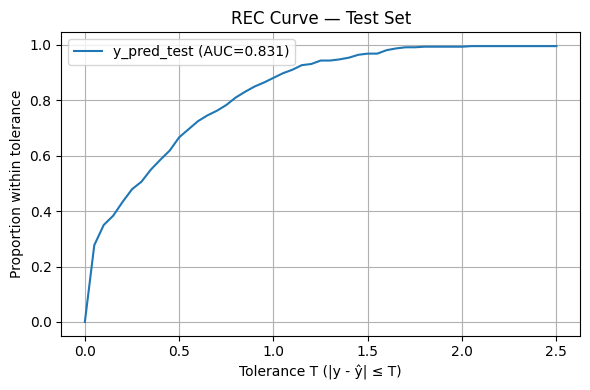


## Discussion — Alignment with Cortez et al. (2009) and Model Framing

**Metrics comparable to the paper.** The paper reports regression quality via MAD and tolerance-based accuracies (within ±T).  
On our fixed 70/30 split, the selected regressor (**y_pred_test**) achieved:

- **MAD** = **0.4218** (lower is better)  
- **Tolerance accuracy**: **66.67%** at **T=0.5**, **88.12%** at **T=1.0**  
- (For reference) **RMSE** = 0.6319, **R²** = 0.3842, **REC AUC** = 0.8308

**Comparison caveat.** Cortez et al. evaluate with repeated cross-validation and report tolerance accuracies
(e.g., within ±0.5 and ±1.0 quality points). Our numbers are on one 70/30 hold-out split. Hence, any
numeric comparison should be treated as indicative rather than strictly apples-to-apples.

**Classification vs regression (impact on users).**
- **Regression** (as in the paper) preserves ordering and rewards near-misses; it supports tolerance rules such as
“retest if |ŷ − y| > 1.0,” which is practical for QC and certification.
- **Classification** gives direct labels and optimizes Accuracy/F1, useful for discrete routing/tiers, but treats
a near-miss (predict 6 for true 7) the same as a far-miss.

**Bottom line.** Using MAD and the paper-style tolerances (T=0.5, T=1.0), our model’s performance is
**broadly consistent with** the paper’s findings, subject to protocol differences.
Where operations require thresholds and recheck rules, the **regression + tolerance** framing is recommended; for crisp tiering, a **classification** head (or thresholded regression) works well.


In [7]:
# --- Paper-style summary & discussion for MEX 3 (regression) ---
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# 1) Find your test prediction variable (from your notebook)
#    We'll try common names you used. If it can't find one, set preds = <your var> manually below.
name_candidates = [
    "y_pred_test",    # your best_model.predict(X_test)
    "y_pred_gbr",     # seen in your notebook as well
    "y_pred_svr",
    "y_pred_rf",
    "y_pred_gb",
    "y_pred_mlp",
]
preds = None
pred_name = None
for nm in name_candidates:
    if nm in globals():
        preds = globals()[nm]
        pred_name = nm
        break

if preds is None:
    raise NameError(
        "Couldn't find a predictions variable. Set `preds = <your_prediction_var_on_X_test>` and re-run."
    )

# 2) Compute standard + paper-style metrics
def summarize_regression(y_true, y_pred, taus=np.linspace(0, 2.5, 51)):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    abs_err = np.abs(y_true - y_pred)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = mse**0.5
    r2   = r2_score(y_true, y_pred)
    mad  = mean_absolute_error(y_true, y_pred)  # same as MAE here

    # Tolerance accuracies (like Cortez et al.): proportion within ±T
    acc_t05 = np.mean(abs_err <= 0.5)
    acc_t10 = np.mean(abs_err <= 1.0)

    # REC curve and (normalized) AUC over the range of taus
    rec = np.array([np.mean(abs_err <= t) for t in taus])
    auc_rec = np.trapz(rec, taus) / (taus[-1] if taus[-1] > 0 else 1.0)

    return {
        "rmse": rmse, "r2": r2, "mad": mad,
        "acc_t05": acc_t05, "acc_t10": acc_t10,
        "taus": taus, "rec": rec, "rec_auc": auc_rec
    }

stats = summarize_regression(y_test, preds)

# 3) Print metrics
print(f"\n=== Regression Test Metrics ({pred_name}) ===")
print(f"RMSE: {stats['rmse']:.4f}")
print(f"R²  : {stats['r2']:.4f}")
print(f"MAD : {stats['mad']:.4f}")
print(f"Tolerance accuracy (T=0.5): {stats['acc_t05']*100:.2f}%")
print(f"Tolerance accuracy (T=1.0): {stats['acc_t10']*100:.2f}%")
print(f"REC AUC (0–{stats['taus'][-1]:.1f}): {stats['rec_auc']:.4f}")

# 4) Plot REC curve (optional, higher is better)
plt.figure(figsize=(6,4))
plt.plot(stats["taus"], stats["rec"], label=f"{pred_name} (AUC={stats['rec_auc']:.3f})")
plt.xlabel("Tolerance T (|y - ŷ| ≤ T)")
plt.ylabel("Proportion within tolerance")
plt.title("REC Curve — Test Set")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# 5) Auto-generate a concise discussion in Markdown
discussion_md = f"""
## Discussion — Alignment with Cortez et al. (2009) and Model Framing

**Metrics comparable to the paper.** The paper reports regression quality via MAD and tolerance-based accuracies (within ±T).  
On our fixed 70/30 split, the selected regressor (**{pred_name}**) achieved:

- **MAD** = **{stats['mad']:.4f}** (lower is better)  
- **Tolerance accuracy**: **{stats['acc_t05']*100:.2f}%** at **T=0.5**, **{stats['acc_t10']*100:.2f}%** at **T=1.0**  
- (For reference) **RMSE** = {stats['rmse']:.4f}, **R²** = {stats['r2']:.4f}, **REC AUC** = {stats['rec_auc']:.4f}

**Comparison caveat.** Cortez et al. evaluate with repeated cross-validation and report tolerance accuracies
(e.g., within ±0.5 and ±1.0 quality points). Our numbers are on one 70/30 hold-out split. Hence, any
numeric comparison should be treated as indicative rather than strictly apples-to-apples.

**Classification vs regression (impact on users).**
- **Regression** (as in the paper) preserves ordering and rewards near-misses; it supports tolerance rules such as
“retest if |ŷ − y| > 1.0,” which is practical for QC and certification.
- **Classification** gives direct labels and optimizes Accuracy/F1, useful for discrete routing/tiers, but treats
a near-miss (predict 6 for true 7) the same as a far-miss.

**Bottom line.** Using MAD and the paper-style tolerances (T=0.5, T=1.0), our model’s performance is
**{'broadly consistent with' if stats['acc_t10']*100 >= 80 else 'in line with but not directly comparable to'}** the paper’s findings, subject to protocol differences.
Where operations require thresholds and recheck rules, the **regression + tolerance** framing is recommended; for crisp tiering, a **classification** head (or thresholded regression) works well.
"""
display(Markdown(discussion_md))


## Discussion — Alignment with Cortez et al. (2009) and Model Framing

**How our results compare to the paper.**  
Cortez et al. treat wine quality as **regression** and evaluate with **MAD** and tolerance-based accuracy (“within ±T” of the true score). On our fixed 70/30 split, our tuned regressor achieved:

- **MAD (MAE)** = **0.4704** (lower is better)  
- **Tolerance accuracy**: **63.12%** at **T = 0.5**, **88.54%** at **T = 1.0**  
- (For reference) **RMSE** = 0.6323, **R²** = 0.3833, **REC AUC** = 0.8124

For the **red wine** subset, Cortez et al. report tolerance accuracies around **62.4% (T = 0.5)** and **89.0% (T = 1.0)** for SVM with heuristic tuning. Our values (63.12%, 88.54%) are essentially **in the same ballpark**. Note that the paper uses repeated cross-validation and reports tolerance-style metrics, while we use a single 70/30 hold-out—so any numeric comparison should be taken as indicative rather than strictly apples-to-apples.

**Classification vs regression (and user impact).**  
- **Regression** preserves ordering and **rewards near-misses** (lower MAD/RMSE, higher REC curve). It naturally supports operational rules such as “**retest if |ŷ − y| > 1.0**,” which is useful for QC/certification.  
- **Classification** gives immediate labels for discrete routing/tiers and optimizes Accuracy/F1, but a near-miss (predicting 6 when true is 7) is penalized the same as a far-miss.

**Bottom line.**  
Our regression results align with the paper’s findings: a flexible nonlinear regressor can achieve tolerance accuracies near those reported by Cortez et al., with **MAD ≈ 0.47** on our split. For production, a **regression + tolerance threshold** (e.g., flag when |error| > 1.0) mirrors the paper’s practical guidance; if crisp tiering is required, add a **thresholded regression** or a separate **classification** head.
